# Import Libraries

In [25]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from utils.plots import plot_avg_confidence

# Load the Data

In [26]:
data_file = '../../data/preprocessed/memory_task_data_preprocessed.csv'
df = pd.read_csv(data_file)

# Data Analysis

## Accuracy

### Spatial

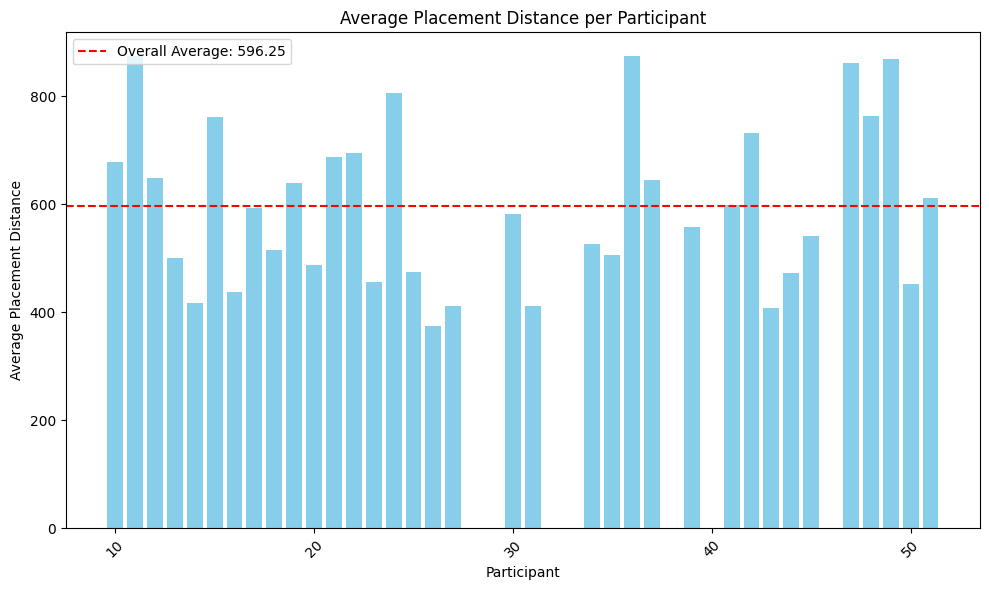

In [40]:
# Select only columns with old_new_new == True
old_stimuli_only_df = df[df['old_new_old'] == True]
# Plot mean spatial distance per participant
avg_distance_per_participant = old_stimuli_only_df.groupby('Participant')['placement_distance'].mean()
avg_distance = old_stimuli_only_df['placement_distance'].mean()
plt.figure(figsize=(10, 6))
plt.bar(avg_distance_per_participant.index, avg_distance_per_participant.values, color='skyblue')
plt.axhline(y=avg_distance, color='r', linestyle='--', label=f'Overall Average: {avg_distance:.2f}')
plt.legend()
plt.xlabel('Participant')
plt.ylabel('Average Placement Distance')
plt.title('Average Placement Distance per Participant')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

R-squared: 0.0611, p-value: 0.0000


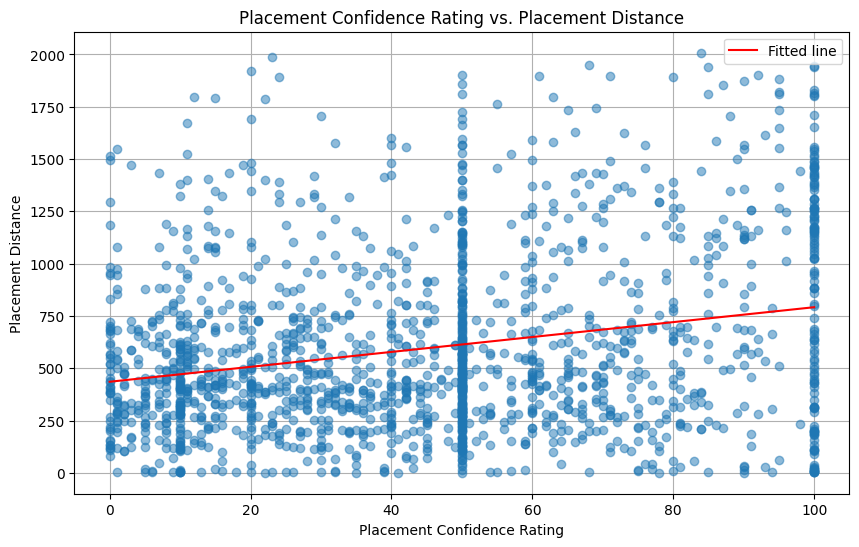

In [45]:
# Plot distance to placement_cr 
plt.figure(figsize=(10, 6))
plt.plot(old_stimuli_only_df['placement_cr'], old_stimuli_only_df['placement_distance'], 'o', alpha=0.5)
plt.xlabel('Placement Confidence Rating')
plt.ylabel('Placement Distance')
plt.title('Placement Confidence Rating vs. Placement Distance')
plt.grid()

# Fit a statistical model to see if placement_cr predicts placement_distance
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(old_stimuli_only_df['placement_cr'], old_stimuli_only_df['placement_distance'])

print(f'R-squared: {r_value**2:.4f}, p-value: {p_value:.4f}')
x = np.linspace(0, 100, 100)
y = intercept + slope * x
plt.plot(x, y, 'r', label='Fitted line')
plt.legend()   
plt.show()


/var/folders/fc/sbtv4zc9113_kb2r0m_b6wx80000gn/T/ipykernel_31260/3506928359.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([group0, group1], labels=labels, patch_artist=True,


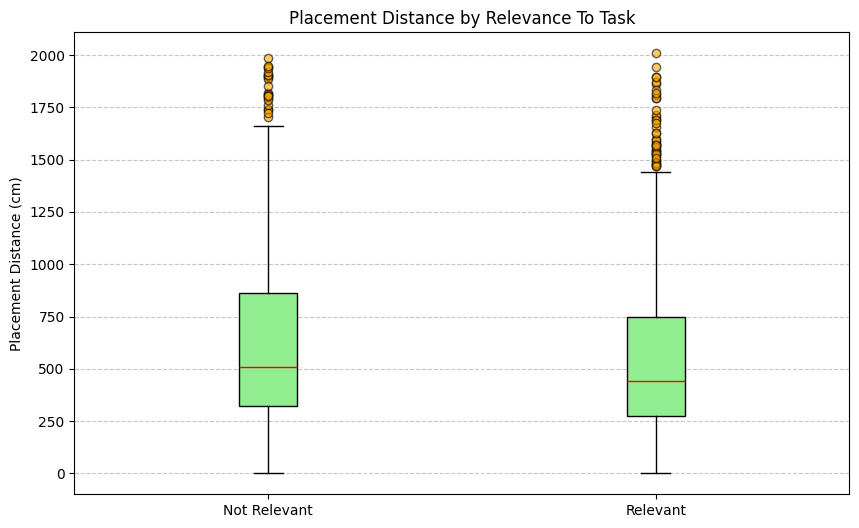

T-test between relevance groups: t-statistic = 2.8232, p-value = 0.0048


In [72]:
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Prepare data
group0 = old_stimuli_only_df[old_stimuli_only_df['relevance_r'] == 0]['placement_distance']
group1 = old_stimuli_only_df[old_stimuli_only_df['relevance_r'] == 1]['placement_distance']

# Boxplot
labels = ['Not Relevant', 'Relevant']
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([group0, group1], labels=labels, patch_artist=True,
           boxprops=dict(facecolor='lightgreen', color='black'),
           medianprops=dict(color='red'),
           whiskerprops=dict(color='black'),
           capprops=dict(color='black'),
           flierprops=dict(markerfacecolor='orange', marker='o', alpha=0.6))

ax.set_ylabel('Placement Distance (cm)')
ax.set_title('Placement Distance by Relevance To Task')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# T-test
t_stat, p_val = ttest_ind(group0, group1)
print(f'T-test between relevance groups: t-statistic = {t_stat:.4f}, p-value = {p_val:.4f}')


### Temporal

In [53]:
def temporal_accuracy(row):
    if row['seen_when_never'] and row['old_new_new'] :
        return True  # Correctly identified new item as never seen
    elif row['seen_when_yesterday'] and row['encoding_no_e3'] :
        return True  # Correctly identified yesterday item
    elif row['seen_when_one_week'] and row['encoding_no_e2'] :
        return True  # Correctly identified one week ago item
    elif row['seen_when_two_weeks'] and row['encoding_no_e1'] :
        return True  # Correctly identified two weeks ago item
    else:
        return False  # Incorrect identification
df['temporal_accuracy'] = df.apply(temporal_accuracy, axis=1)


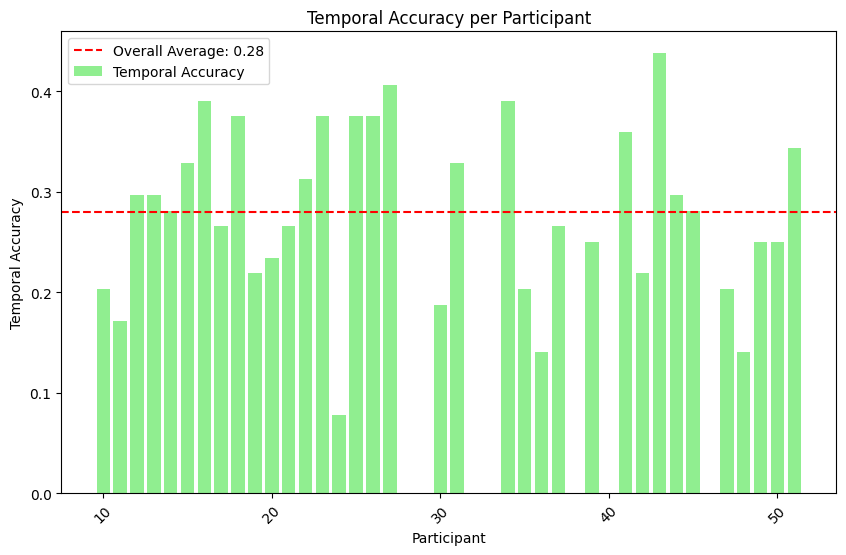

In [54]:
# Plot temporal accuracy per participant
temporal_accuracy_per_participant = df.groupby('Participant')['temporal_accuracy'].mean()
avg_temporal_accuracy = df['temporal_accuracy'].mean()
plt.figure(figsize=(10, 6))
bars1 = plt.bar(temporal_accuracy_per_participant.index, temporal_accuracy_per_participant.values, color='lightgreen', label='Temporal Accuracy')
plt.axhline(y=avg_temporal_accuracy, color='r', linestyle='--', label=f'Overall Average: {avg_temporal_accuracy:.2f}')
plt.legend()
plt.xlabel('Participant')
plt.ylabel('Temporal Accuracy')
plt.title('Temporal Accuracy per Participant')
plt.xticks(rotation=45)
plt.show()

/var/folders/fc/sbtv4zc9113_kb2r0m_b6wx80000gn/T/ipykernel_31260/1605687723.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = df.groupby('confidence_bin')['temporal_accuracy'].mean()


R-squared: 0.0052, p-value: 0.0006


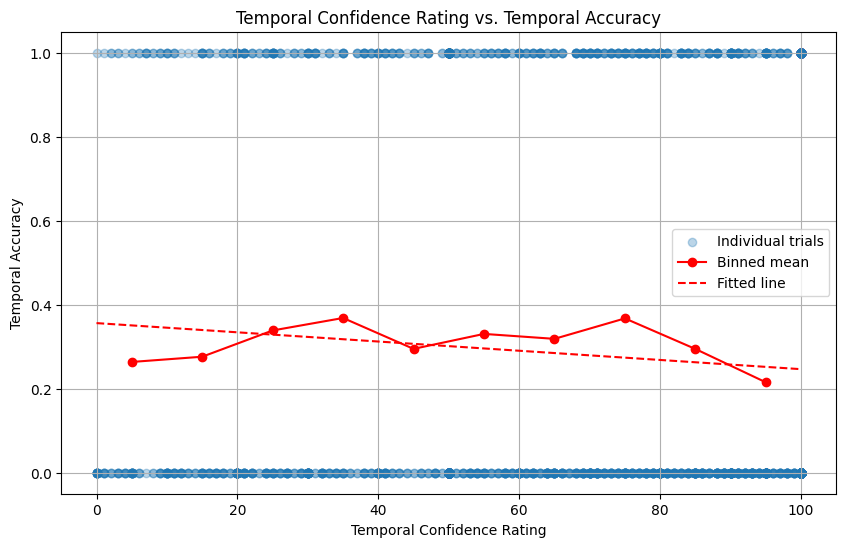

In [74]:
# Define bins
confidence_bins = np.arange(0, 110, 10)
bin_labels = [f'{confidence_bins[i]}-{confidence_bins[i+1]}' for i in range(len(confidence_bins)-1)]
df['confidence_bin'] = pd.cut(df['seen_when_cr'], bins=confidence_bins, labels=bin_labels, include_lowest=True)

# Compute mean temporal accuracy per bin
bin_means = df.groupby('confidence_bin')['temporal_accuracy'].mean()
bin_centers = [np.mean([confidence_bins[i], confidence_bins[i+1]]) for i in range(len(confidence_bins)-1)]

plt.figure(figsize=(10, 6))
plt.scatter(df['seen_when_cr'], df['temporal_accuracy'], alpha=0.3, label='Individual trials')
plt.plot(bin_centers, bin_means, 'o-', color='red', label='Binned mean')

plt.xlabel('Temporal Confidence Rating')
plt.ylabel('Temporal Accuracy')
plt.title('Temporal Confidence Rating vs. Temporal Accuracy')
plt.grid(True)
plt.legend()

# Fit a linear model
slope, intercept, r_value, p_value, std_err = stats.linregress(df['seen_when_cr'], df['temporal_accuracy'])
x_fit = np.linspace(0, 100, 100)
y_fit = intercept + slope * x_fit
plt.plot(x_fit, y_fit, 'r--', label='Fitted line')
plt.legend()

print(f'R-squared: {r_value**2:.4f}, p-value: {p_value:.4f}')
plt.show()

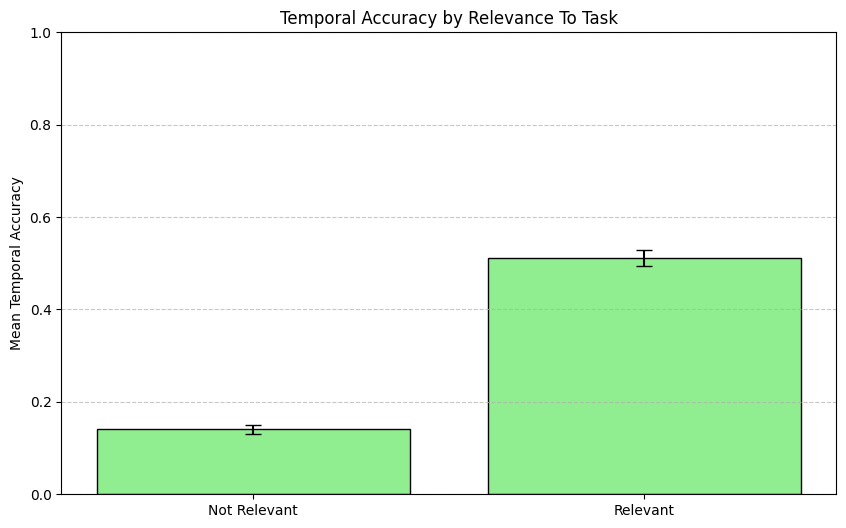

T-test between relevance groups: t-statistic = -20.6631, p-value = 0.0000


In [78]:

# Prepare data
group0 = df[df['relevance_r'] == 0]['temporal_accuracy']
group1 = df[df['relevance_r'] == 1]['temporal_accuracy']

means = [group0.mean(), group1.mean()]
sems = [group0.std()/np.sqrt(len(group0)), group1.std()/np.sqrt(len(group1))]
labels = ['Not Relevant', 'Relevant']
x = np.arange(len(labels))

# Bar plot with error bars
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, means, yerr=sems, color='lightgreen', edgecolor='black', capsize=6)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Mean Temporal Accuracy')
ax.set_title('Temporal Accuracy by Relevance To Task')
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# T-test
t_stat, p_val = ttest_ind(group0, group1)
print(f'T-test between relevance groups: t-statistic = {t_stat:.4f}, p-value = {p_val:.4f}')


## Confidence Ratings

### Per Participant

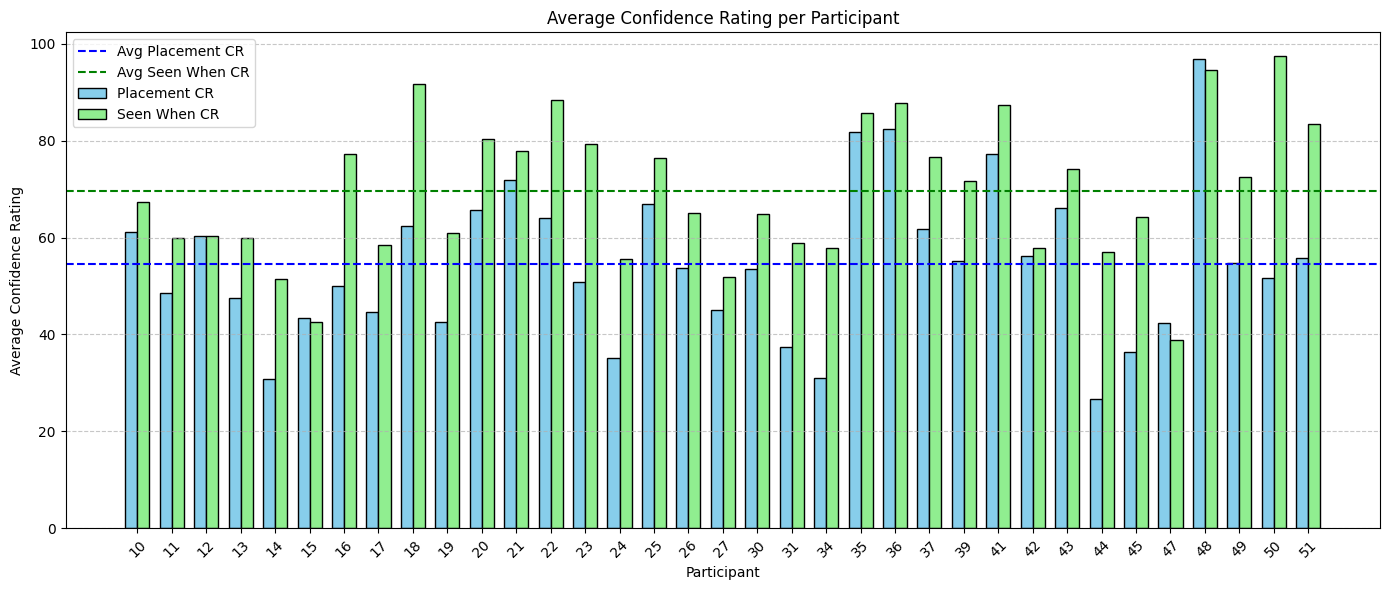

In [36]:
# Data
participants = avg_placement_cr_per_participant.index
placement_values = avg_placement_cr_per_participant.values
seen_when_values = avg_seen_when_cr_per_participant.values

x = np.arange(len(participants))
width = 0.35

plt.figure(figsize=(14, 6))
# Side-by-side bars
bars1 = plt.bar(x - width/2, placement_values, width, label='Placement CR', color='skyblue', edgecolor='black')
bars2 = plt.bar(x + width/2, seen_when_values, width, label='Seen When CR', color='lightgreen', edgecolor='black')

# Average lines
plt.axhline(y=avg_placement_cr, color='blue', linestyle='--', label='Avg Placement CR')
plt.axhline(y=avg_seen_when_cr, color='green', linestyle='--', label='Avg Seen When CR')

# Labels and title
plt.xlabel('Participant')
plt.ylabel('Average Confidence Rating')
plt.title('Average Confidence Rating per Participant')
plt.xticks(x, participants, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Per Category

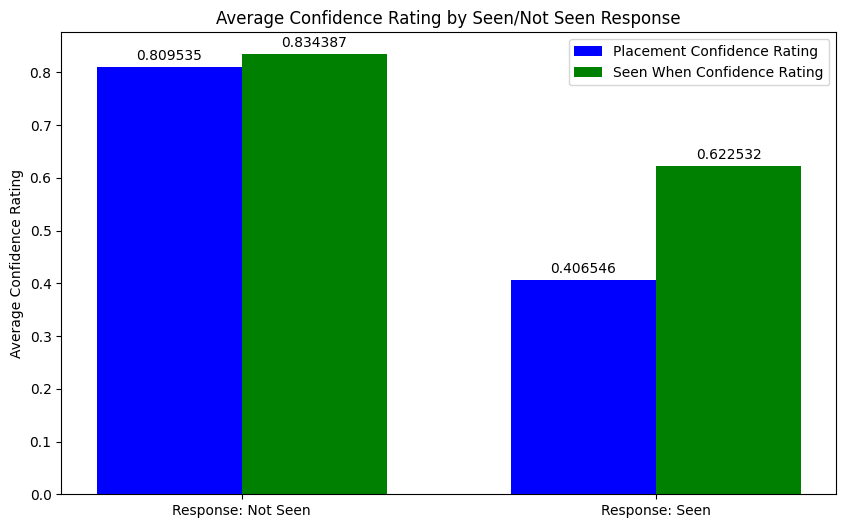

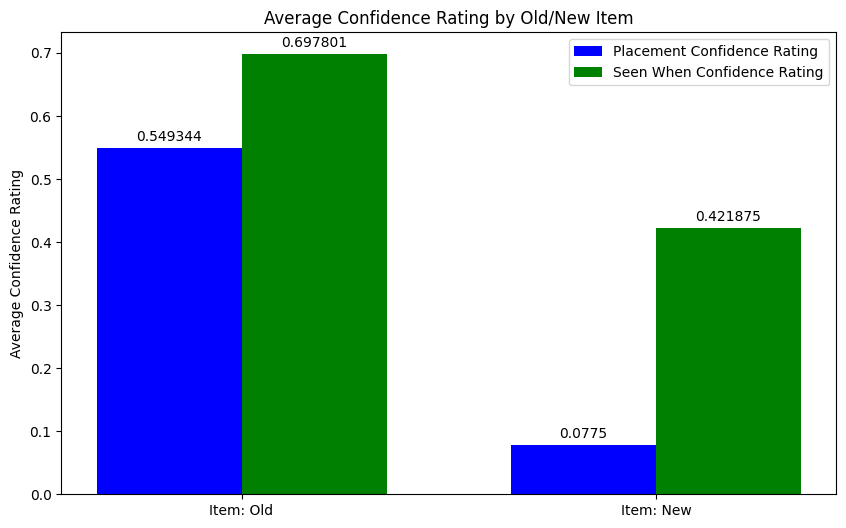

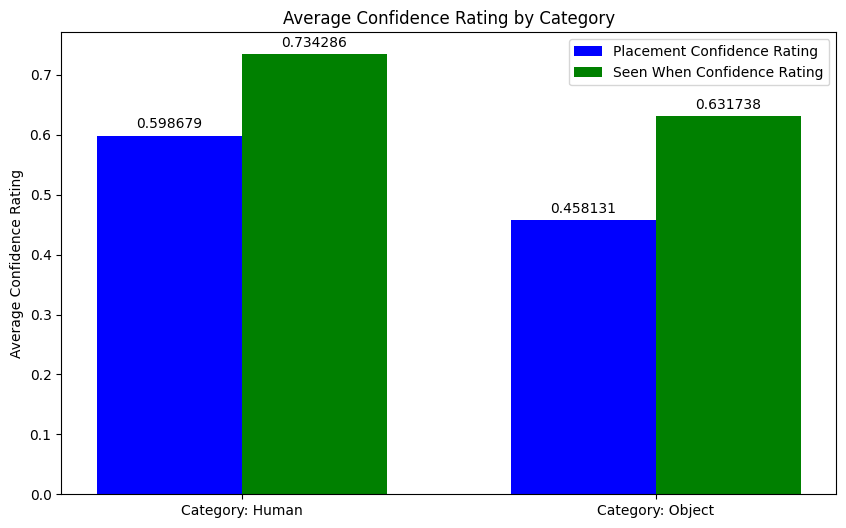

In [29]:
plot_avg_confidence(df, group_col='response_seen', group_labels=['Response: Not Seen', 'Response: Seen'],
                    title='Average Confidence Rating by Seen/Not Seen Response')
plot_avg_confidence(df, group_col='old_new_new', group_labels=['Item: Old', 'Item: New'],
                title='Average Confidence Rating by Old/New Item')
plot_avg_confidence(df, group_col='catego_h', group_labels=['Category: Human', 'Category: Object'],
                    title='Average Confidence Rating by Category')